<a href="https://colab.research.google.com/github/arjunnp20-design/first/blob/main/auto_imports_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PRCP-1017-AUTO PRICE PRED**

**TEAM'S CODE : PTIC-CDS-MAY-26-11231**

**PROBLEM STATEMENT**

TASK 1 :prepare a complete data analysis report on the given data.

TASK 2 : Create a predictive model by applying some data science techiniques for the price of cars with the avaiable independent variables.They can accordingly manipulate the design of the car,the business stratergy etc to meet certain price levels.

**ATTRIBUTE INFORMATION**

*   SYMBOLING: -3,-2,-1,0,1,2,3
*   NORMALIZED-LOSSES:continous from 65 to 256.
*   MAKE:Alfa Romeo,Audi,BMW,Chevrolet,Dodge,Honda,Isuzu,Jaquar,Mazda,Mercedes-Benz,Mercury,Mitsubishi,Nissian,Peugot,Plymoth,Porchese,Renault,Saab,Toyota,Volkswagen,volvo.
*   FUEL TYPE: DIESEL,GAS
*   ASPIRATION :std,turbo
*   num of doors: four,two
*   BODY STYLE: HARDTOP,WAGON,SEDAN,HATCHBACK CONVERTIBLE.
*   DIRVE WHEELS:4WD,FWD,RWD
*   ENGINE LOCATION:FRONT REAR
*   WHEEL BASE CONTINOUS FROM 86.6 TO 120.9
*   LENGTH : FROM 142.1 TO 208.1
*   WIDTH: FROM 60.3 TO 72.3
*   HEIGHT : FROM 47.8 TO 59.8
*   CURB-WEIGHT: FROM 1488 TO 4066
*   ENGINE-TYPE: DOHC DOHCV I IHC OHCV ROTOR
*   NUM OF CYLINDERS:8 5 4 6 3 12 2
*   ENGINE-SIZE: FROM 61 TO 326
*   FUEL-SYSTEM:1BBL,2BBL,4BBL,IDI,MPFI,MFI,SPDI,SPFI
*   BORE: FROM 2.54 TO 3.94
*   STOKE :2.07 TO 4.17
*   COMPRESSION-RATIO: FROM 7 TO 23
*   HORSEPOWER: FROM 48 TO 288
*   PEAK RPM:FROM 4150 TO 6600
*   CITY MPG: FROM 13 TO 49
*   HIGHWAY MPG FROM 16 TO 54


#**EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
columns = [
    "symboling",
    "normalized_losses",
    "make",
    "fuel_type",
    "aspiration",
    "num_of_doors",
    "body_style",
    "drive_wheels",
    "engine_location",
    "wheel_base",
    "length",
    "width",
    "height",
    "curb_weight",
    "engine_type",
    "num_of_cylinders",
    "engine_size",
    "fuel_system",
    "bore",
    "stroke",
    "compression_ratio",
    "horsepower",
    "peak_rpm",
    "city_mpg",
    "highway_mpg",
    "price"
]

In [ ]:
data = pd.read_csv('auto_imports.csv',header = None, names = columns)

In [ ]:
data

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [ ]:
data.head()


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized_losses  201 non-null    object 
 2   make               201 non-null    object 
 3   fuel_type          201 non-null    object 
 4   aspiration         201 non-null    object 
 5   num_of_doors       201 non-null    object 
 6   body_style         201 non-null    object 
 7   drive_wheels       201 non-null    object 
 8   engine_location    201 non-null    object 
 9   wheel_base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb_weight        201 non-null    int64  
 14  engine_type        201 non-null    object 
 15  num_of_cylinders   201 non-null    object 
 16  engine_size        201 non

### Observation:

From the `data.info()` output, we can observe the following data types:

*   **Numerical Data**: There are columns with `int64` (e.g., column `3`, `2548`, `130`, `21`, `27`, `13495`) and `float64` (e.g., `88.60`, `168.80`, `64.10`, `48.80`, `9.00`). These represent continuous numerical values.

*   **Categorical Data**: A significant number of columns are of `object` dtype (e.g., `?`, `alfa-romero`, `gas`, `std`, `two`, `convertible`, `rwd`, `front`, `dohc`, `four`, `mpfi`, `3.47`, `2.68`, `111`, `5000`). These typically represent string or mixed type data, which, in the context of car attributes, are likely categorical features. Some of these `object` columns (`3.47`, `2.68`, `111`, `5000`) might actually be numerical values that were read as strings due to special characters (like '?') or inconsistent formatting, and would need to be converted to numeric types after handling missing values.

It's important to properly handle the `object` columns, especially those that should be numerical, by converting them to appropriate numeric types and addressing any missing values (represented by `?` in the dataset as seen in `data.head()`).

In [ ]:
data = data.replace('?', pd.NA)

In [ ]:
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

normalized_losses    37
num_of_doors          2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
dtype: int64


In [ ]:
data.shape

(201, 26)

In [ ]:
data['symboling'].unique()

array([ 3,  1,  2,  0, -1, -2])

In [ ]:
data['aspiration'].unique()

array(['std', 'turbo'], dtype=object)

In [ ]:
data['normalized_losses'].unique()

array([<NA>, '164', '158', '192', '188', '121', '98', '81', '118', '148',
       '110', '145', '137', '101', '78', '106', '85', '107', '104', '113',
       '150', '129', '115', '93', '142', '161', '153', '125', '128',
       '122', '103', '168', '108', '194', '231', '119', '154', '74',
       '186', '83', '102', '89', '87', '77', '91', '134', '65', '197',
       '90', '94', '256', '95'], dtype=object)

In [ ]:
data['body_style'].unique()

array(['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop'],
      dtype=object)

In [ ]:
data['bore'].unique()

array(['3.47', '2.68', '3.19', '3.13', '3.50', '3.31', '3.62', '2.91',
       '3.03', '2.97', '3.34', '3.60', '2.92', '3.15', '3.43', '3.63',
       '3.54', '3.08', <NA>, '3.39', '3.76', '3.58', '3.46', '3.80',
       '3.78', '3.17', '3.35', '3.59', '2.99', '3.33', '3.70', '3.61',
       '3.94', '3.74', '2.54', '3.05', '3.27', '3.24', '3.01'],
      dtype=object)

In [ ]:
data['city_mpg'].unique()

array([21, 19, 24, 18, 17, 23, 20, 16, 15, 47, 38, 37, 31, 49, 30, 27, 25,
       13, 26, 36, 22, 14, 45, 28, 32, 35, 34, 29, 33])

In [ ]:
data['compression_ratio'].unique()

array([ 9.  , 10.  ,  8.  ,  8.5 ,  8.3 ,  8.8 ,  9.5 ,  9.6 ,  9.41,
        9.4 ,  7.6 ,  7.  ,  9.2 , 10.1 ,  9.1 ,  8.1 , 11.5 ,  8.6 ,
       22.7 , 22.  , 21.5 ,  7.5 , 21.9 ,  7.8 ,  8.4 , 21.  ,  8.7 ,
        9.31,  9.3 ,  7.7 , 22.5 , 23.  ])

In [ ]:
data['curb_weight'].unique()

array([2548, 2823, 2337, 2824, 2507, 2844, 2954, 3086, 2395, 2710, 2765,
       3055, 3230, 3380, 3505, 1488, 1874, 1909, 1876, 2128, 1967, 1989,
       2191, 2535, 2811, 1713, 1819, 1837, 1940, 1956, 2010, 2024, 2236,
       2289, 2304, 2372, 2465, 2293, 2734, 4066, 3950, 1890, 1900, 1905,
       1945, 1950, 2380, 2385, 2500, 2410, 2443, 2425, 2670, 2700, 3515,
       3750, 3495, 3770, 3740, 3685, 3900, 3715, 2910, 1918, 1944, 2004,
       2145, 2370, 2328, 2833, 2921, 2926, 2365, 2405, 2403, 1889, 2017,
       1938, 1951, 2028, 1971, 2037, 2008, 2324, 2302, 3095, 3296, 3060,
       3071, 3139, 3020, 3197, 3430, 3075, 3252, 3285, 3485, 3130, 2818,
       2778, 2756, 2800, 2579, 2460, 2658, 2695, 2707, 2758, 2808, 2847,
       2050, 2120, 2240, 2190, 2340, 2510, 2290, 2455, 2420, 2650, 1985,
       2040, 2015, 2280, 3110, 2081, 2109, 2275, 2094, 2122, 2140, 2169,
       2204, 2265, 2300, 2540, 2536, 2551, 2679, 2714, 2975, 2326, 2480,
       2414, 2458, 2976, 3016, 3131, 3151, 2261, 22

In [ ]:
data['drive_wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

In [ ]:
data['engine_location'].unique()

array(['front', 'rear'], dtype=object)

In [ ]:
data['engine_size'].unique()

array([130, 152, 109, 136, 131, 108, 164, 209,  61,  90,  98, 122, 156,
        92,  79, 110, 111, 119, 258, 326,  91,  70,  80, 140, 134, 183,
       234, 308, 304,  97, 103, 120, 181, 151, 194, 132, 121, 146, 171,
       161, 141, 173, 145])

In [ ]:
data['engine_type'].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf'], dtype=object)

In [ ]:
data['fuel_system'].unique()

array(['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', '4bbl', 'idi', 'spdi'],
      dtype=object)

In [ ]:
data['fuel_type'].unique()

array(['gas', 'diesel'], dtype=object)

In [ ]:
data['height'].unique()

array([48.8, 52.4, 54.3, 53.1, 55.7, 55.9, 53.7, 56.3, 53.2, 52. , 50.8,
       50.6, 59.8, 50.2, 52.6, 54.5, 58.3, 53.3, 54.1, 51. , 53.5, 51.4,
       52.8, 47.8, 49.6, 55.5, 54.4, 56.5, 58.7, 54.9, 56.7, 55.4, 54.8,
       49.4, 51.6, 54.7, 55.1, 56.1, 49.7, 56. , 55.2, 50.5, 52.5, 53. ,
       59.1, 53.9, 55.6, 56.2, 57.5])

In [ ]:
data['highway_mpg'].unique()

array([27, 26, 30, 22, 25, 20, 29, 28, 53, 43, 41, 38, 24, 54, 42, 34, 33,
       31, 19, 17, 23, 32, 39, 18, 16, 37, 50, 36, 47, 46])

In [ ]:
data['horsepower'].unique()

array(['111', '154', '102', '115', '110', '140', '101', '121', '182',
       '48', '70', '68', '88', '145', '58', '76', '60', '86', '100', '78',
       '90', '176', '262', '135', '84', '64', '120', '72', '123', '155',
       '184', '175', '116', '69', '55', '97', '152', '160', '200', '95',
       '142', '143', '207', <NA>, '73', '82', '94', '62', '56', '112',
       '92', '161', '156', '52', '85', '114', '162', '134', '106'],
      dtype=object)

In [ ]:
data['length'].unique()

array([168.8, 171.2, 176.6, 177.3, 192.7, 176.8, 189. , 193.8, 197. ,
       141.1, 155.9, 158.8, 157.3, 174.6, 173.2, 144.6, 150. , 163.4,
       157.1, 167.5, 175.4, 169.1, 170.7, 172.6, 199.6, 191.7, 159.1,
       166.8, 169. , 177.8, 175. , 190.9, 187.5, 202.6, 180.3, 208.1,
       199.2, 178.4, 173. , 172.4, 165.3, 170.2, 165.6, 162.4, 173.4,
       181.7, 184.6, 178.5, 186.7, 198.9, 167.3, 168.9, 181.5, 186.6,
       156.9, 157.9, 172. , 173.5, 173.6, 158.7, 169.7, 166.3, 168.7,
       176.2, 175.6, 183.5, 187.8, 171.7, 159.3, 165.7, 180.2, 183.1,
       188.8])

In [ ]:
data['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [ ]:
data['normalized_losses'].unique()

array([<NA>, '164', '158', '192', '188', '121', '98', '81', '118', '148',
       '110', '145', '137', '101', '78', '106', '85', '107', '104', '113',
       '150', '129', '115', '93', '142', '161', '153', '125', '128',
       '122', '103', '168', '108', '194', '231', '119', '154', '74',
       '186', '83', '102', '89', '87', '77', '91', '134', '65', '197',
       '90', '94', '256', '95'], dtype=object)

In [ ]:
data['num_of_cylinders'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [ ]:
data['num_of_doors'].unique()

array(['two', 'four', <NA>], dtype=object)

In [ ]:
data['peak_rpm'].unique()

array(['5000', '5500', '5800', '4250', '5400', '5100', '4800', '6000',
       '4750', '4650', '4200', '4350', '4500', '5200', '4150', '5600',
       '5900', <NA>, '5250', '4900', '4400', '6600', '5300'], dtype=object)

In [ ]:
print(data.duplicated().sum())

0


In [ ]:
data['price'].describe()

,price
count,201.000000
mean,13207.129353
std,7947.066342
min,5118.000000
25%,7775.000000
50%,10295.000000
75%,16500.000000
max,45400.000000


In [ ]:
data['stroke'].describe()

,stroke
count,197
unique,36
top,3.40
freq,19


In [ ]:
data['width'].describe()

,width
count,201.000000
mean,65.889055
std,2.101471
min,60.300000
25%,64.100000
50%,65.500000
75%,66.600000
max,72.000000


In [ ]:
data['city_mpg'].describe()

,city_mpg
count,201.000000
mean,25.179104
std,6.423220
min,13.000000
25%,19.000000
50%,24.000000
75%,30.000000
max,49.000000


In [ ]:
corr = data.select_dtypes(include='number').corr()

corr

,symboling,wheel_base,length,width,height,curb_weight,engine_size,compression_ratio,city_mpg,highway_mpg,price
symboling,1.000000,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.182196,-0.035527,0.036233,-0.082391
wheel_base,-0.535987,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.250313,-0.470606,-0.543304,0.584642
length,-0.365404,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.159733,-0.665192,-0.698142,0.690628
width,-0.242423,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.189867,-0.633531,-0.680635,0.751265
height,-0.550160,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.259737,-0.049800,-0.104812,0.135486
curb_weight,-0.233118,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.156433,-0.749543,-0.794889,0.834415
engine_size,-0.110581,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.028889,-0.650546,-0.679571,0.872335
compression_ratio,-0.182196,0.250313,0.159733,0.189867,0.259737,0.156433,0.028889,1.000000,0.331425,0.268465,0.071107
city_mpg,-0.035527,-0.470606,-0.665192,-0.633531,-0.049800,-0.749543,-0.650546,0.331425,1.000000,0.972044,-0.686571
highway_mpg,0.036233,-0.543304,-0.698142,-0.680635,-0.104812,-0.794889,-0.679571,0.268465,0.972044,1.000000,-0.704692


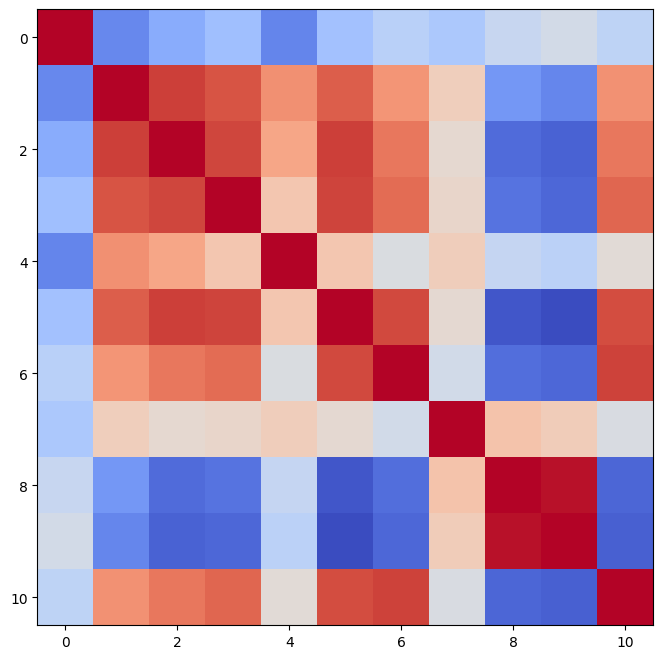

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,8))
plt.imshow(corr,cmap = "coolwarm")
plt.show()


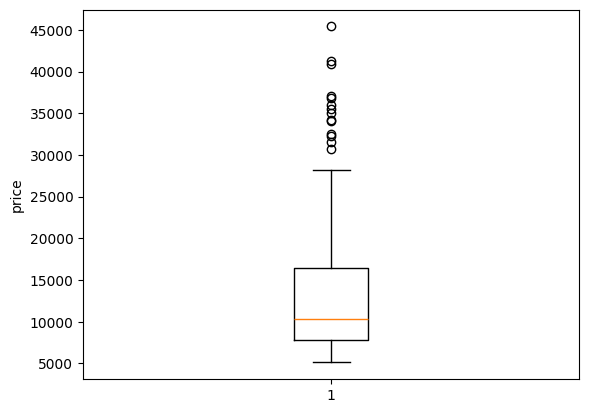

In [ ]:
plt.boxplot(data['price'].dropna())
plt.ylabel('price')
plt.show()

In [ ]:
q1 = data['price'].quantile(0.25)
q3 = data['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]
print(outliers)

     symboling normalized_losses           make fuel_type aspiration  \
14           0              <NA>            bmw       gas        std   
15           0              <NA>            bmw       gas        std   
16           0              <NA>            bmw       gas        std   
44           0               145         jaguar       gas        std   
45           0              <NA>         jaguar       gas        std   
46           0              <NA>         jaguar       gas        std   
67          -1                93  mercedes-benz    diesel      turbo   
68          -1              <NA>  mercedes-benz       gas        std   
69           3               142  mercedes-benz       gas        std   
70           0              <NA>  mercedes-benz       gas        std   
71           1              <NA>  mercedes-benz       gas        std   
123          3              <NA>        porsche       gas        std   
124          3              <NA>        porsche       gas       

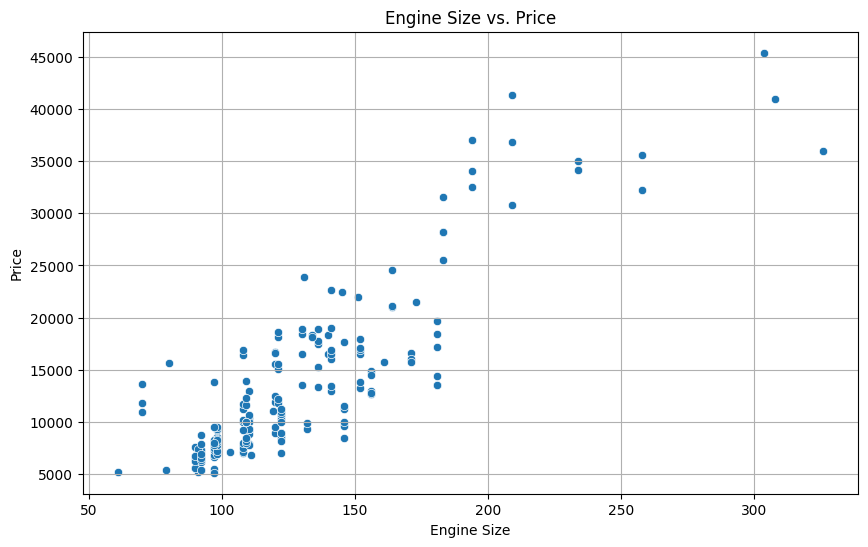

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='engine_size', y='price', data=data)
plt.title('Engine Size vs. Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [ ]:
missing = data.isna().sum()
missing_percentage = (missing / len(data)) * 100
missing_df = pd.DataFrame({'Missing_values': missing,
                           'Percentage': missing_percentage})
print(missing_df[missing_df["Missing_values"]> 0].sort_values('Percentage',ascending = False))

                   Missing_values  Percentage
normalized_losses              37   18.407960
bore                            4    1.990050
stroke                          4    1.990050
num_of_doors                    2    0.995025
horsepower                      2    0.995025
peak_rpm                        2    0.995025


In [ ]:
data['normalized_losses'] = pd.to_numeric(data['normalized_losses'], errors='coerce')
data['normalized_losses'].fillna(data['normalized_losses'].median(), inplace=True)

In [ ]:
data['bore'] = pd.to_numeric(data['bore'], errors='coerce')
data['bore'].fillna(data['bore'].median(), inplace=True)

In [ ]:
data['stroke'] = pd.to_numeric(data['stroke'], errors='coerce')
data['stroke'].fillna(data['stroke'].median(), inplace=True)

In [ ]:
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data['horsepower'].fillna(data['horsepower'].median(), inplace=True)

In [ ]:
data['peak_rpm'] = pd.to_numeric(data['peak_rpm'], errors='coerce')
data['peak_rpm'].fillna(data['peak_rpm'].median(), inplace=True)

## EDA Observation And Conclusion


1.  **Data Loading and Initial Inspection**: Loaded the dataset and assigned meaningful column names. Initial data.info() revealed several columns imported as object dtype that should be numeric, and the presence of '?' characters indicating missing values.

2.  **Missing Value Handling**: Replaced '?' with pd.NA and then imputed numerical columns (normalized_losses, bore, stroke, horsepower, peak_rpm) with their respective medians after converting them to numeric types. The num_of_doors column still has missing values, which will be addressed using pipeline imputation during the preprocessing stage.

3.  **Duplicate Check**: Confirmed there are no duplicate rows in the dataset.

4.  **Univariate Analysis**: Explored unique values for categorical features and descriptive statistics for numerical features like price, stroke, width, and city_mpg. This helped in understanding the distribution and range of individual variables.

5.  **Correlation**: Generated a correlation matrix and heatmap to identify relationships between numerical variables. engine_size, curb_weight, width, and length showed strong positive correlations with price. Conversely, city_mpg and highway_mpg showed strong negative correlations with price. Columns like symboling, height, and compression_ratio showed low correlation with price, suggesting they might be less impactful predictors.

6.  **Outlier**: A boxplot for price indicated the presence of potential outliers, which should be considered during model building.

7.  **Visualizations**: Scatter plots (e.g., engine_size vs. price) confirmed the observed correlations, showing trends and patterns in the data.


#**Pre-Processing**

In [ ]:
from pandas.core.arrays import categorical
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

door_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [ ]:
data = data.drop('symboling', axis=1)

In [ ]:
x=data.drop('price',axis=1)
y=data['price']

In [ ]:
x

,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
1,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27
2,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26
3,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30
4,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,four,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28
197,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,four,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25
198,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,six,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23
199,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,six,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27


In [ ]:
y

,price
0,13495
1,16500
2,16500
3,13950
4,17450
...,...
196,16845
197,19045
198,21485
199,22470


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y)

#**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math

In [ ]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

for col in x_train.select_dtypes(include='object').columns:
    x_train[col] = x_train[col].replace(pd.NA, np.nan)
    x_test[col] = x_test[col].replace(pd.NA, np.nan)

numerical_features = x_train.select_dtypes(include=np.number).columns
categorical_features = x_train.select_dtypes(exclude=np.number).columns

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print('done with preprocessing and scaling')

done with preprocessing and scaling


In [ ]:
modellr = LinearRegression()
modellr.fit(x_train_processed, y_train)


LinearRegression()

In [ ]:
y_pred = modellr.predict(x_test_processed)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rsme = math.sqrt(mse)
print('MSE:', mse)
print('MAE:', mae)
print('R2:', r2)
print('RMSE:', rsme)

MSE: 4276831.298559633
MAE: 1569.0395697889503
R2: 0.8480727369522649
RMSE: 2068.050119934145


In [ ]:
lr_cv_scores = cross_val_score(modellr, x_train_processed, y_train, cv=5, scoring='r2')
print('Cross-Validation RMSE:', lr_cv_scores)

Cross-Validation RMSE: [0.84608745 0.88820777 0.82795047 0.85612697 0.88845865]


In [ ]:
print('train r2:', modellr.score(x_train_processed, y_train))
print('test r2:', modellr.score(x_test_processed, y_test))

train r2: 0.9708453024087287
test r2: 0.8480727369522649


#**Random Forest Regressor**


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
import math

In [ ]:
param_grid = {'n_estimators':[100,200,300,500],'max_depth':[None,5,10,15,20],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4],'max_features':[1.0,'sqrt','log2']}

modelrf = RandomForestRegressor(random_state=42)
rando_search = RandomizedSearchCV(estimator=modelrf,param_distributions=param_grid,n_iter=30,cv=5,scoring='r2',random_state=42,n_jobs=-1)
rando_search.fit(x_train_processed, y_train)
best_modelrf = rando_search.best_estimator_
print(rando_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [ ]:
y_predict_rf = best_modelrf.predict(x_test_processed)
rf_mse = mean_squared_error(y_test, y_predict_rf)
rf_mae = mean_absolute_error(y_test, y_predict_rf)
rf_r2 = r2_score(y_test, y_predict_rf)
rf_rsme = math.sqrt(rf_mse)

print('MSE:', rf_mse)
print('MAE:', rf_mae)
print('R2:', rf_r2)
print('RMSE:', rf_rsme)

MSE: 3945832.0972698727
MAE: 1437.4848513071895
R2: 0.859830928756528
RMSE: 1986.4118649640293


In [ ]:
print('TRAIN R2:',best_modelrf.score(x_train_processed, y_train))
print('TEST R2:',best_modelrf.score(x_test_processed, y_test))

TRAIN R2: 0.9902088004316718
TEST R2: 0.859830928756528


In [ ]:
rf_cv_scores = cross_val_score(best_modelrf, x_train_processed, y_train, cv=5, scoring='r2')
print('Cross-Validation RMSE:', rf_cv_scores)
print('mean cv r2 :',rf_cv_scores.mean())

Cross-Validation RMSE: [0.85005476 0.93922016 0.90602246 0.94797276 0.89528117]
mean cv r2 : 0.9077102647844202


#**Final Model**


the evalution shows that the random forest regressor is the superior model for this projectt as it has returned a r2 value of 90 which is much higher than the linear regression model which only had 84 .therefor the best model is selected as the random forest

## Project Conclusion: Car Price Prediction



### Data Preprocessing and Exploration:
1.  **Data Loading and Cleaning**: The auto_imports.csv dataset was loaded, and appropriate column names were assigned. Initial inspection revealed several columns imported as object dtype that should be numeric, and the presence of '?' characters, which were treated as missing values (`pd.NA`).
2.  **Missing Value Handling**: Missing values in `normalized_losses`, `bore`, `stroke`, `horsepower`, and `peak_rpm` were imputed using their respective medians after converting these columns to numeric types. The `num_of_doors` column's missing values were handled during the preprocessing pipeline. No duplicate rows were found.
3.  **Exploratory Data Analysis (EDA)**:
    *   Correlation analysis showed strong positive correlations between `price` and `engine_size`, `curb_weight`, `width`, and `length`. Conversely, `city_mpg` and `highway_mpg` exhibited strong negative correlations with `price`. Columns like `symboling`, `height`, and `compression_ratio` showed low correlation.
    *   A boxplot of `price` indicated the presence of potential outliers, which were identified but not removed to retain data variability.
4.  **Feature Engineering and Scaling**: The `symboling` column was dropped due to low correlation. A robust preprocessing pipeline was established using `ColumnTransformer`:
    *   Numerical features underwent median imputation and `StandardScaler` for normalization.
    *   Categorical features were processed with most-frequent imputation and `OneHotEncoder`.
    *   Crucially, `pd.NA` values in object columns were converted to `np.nan` before `ColumnTransformer` application to ensure compatibility.

### Model Training and Evaluation:
Two regression models were trained and evaluated:

1.  **Linear Regression**:
    *   The `LinearRegression` model was trained on the preprocessed data.
    *   **Performance Metrics (Test Set)**:
        *   R2 Score: 0.8481
        *   Mean Absolute Error (MAE): 1569.04
        *   Mean Squared Error (MSE): 4,276,831.30
        *   Root Mean Squared Error (RMSE): 2068.05
    *   **Cross-Validation R2 (5-fold)**: Mean R2 of approximately 0.861.
    *   **Observation**: A notable difference between training R2 (0.9708) and test R2 (0.8481) suggested potential overfitting.

2.  **Random Forest Regressor**:
    *   A `RandomForestRegressor` was initialized and hyperparameter tuned using `RandomizedSearchCV` with 30 iterations and 5-fold cross-validation. The best parameters found were `{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}`.
    *   **Performance Metrics (Test Set)**:
        *   R2 Score: 0.8598
        *   Mean Absolute Error (MAE): 1437.48
        *   Mean Squared Error (MSE): 3,945,832.10
        *   Root Mean Squared Error (RMSE): 1986.41
    *   **Cross-Validation R2 (5-fold)**: Mean R2 of approximately 0.9077.
    *   **Observation**: The Random Forest model demonstrated slightly better generalization capabilities compared to Linear Regression, indicated by a higher cross-validation R2.

### Final Model Selection:
Based on the evaluation metrics, the **Random Forest Regressor** is chosen as the superior model for this project. It achieved a higher R2 score on both the test set (0.8598 vs 0.8481) and, more importantly, a significantly higher mean cross-validation R2 (0.9077 vs 0.861) compared to the Linear Regression model. This indicates better predictive power and robustness against unseen data.

### Future Enhancements:
*   **Further Hyperparameter Tuning**: Explore a wider range of hyperparameters for the Random Forest or use more exhaustive search strategies like `GridSearchCV`.
*   **Feature Engineering**: Investigate creating new features from existing ones (e.g., power-to-weight ratio) that might improve model performance.
*   **Ensemble Methods**: Experiment with other ensemble techniques like Gradient Boosting (e.g., XGBoost, LightGBM) for potentially better results.
*   **Outlier Treatment**: A more sophisticated handling of outliers in the 'price' column could be explored.
*   **Data Collection**: If possible, acquiring more data or additional relevant features could further enhance model accuracy.